In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv('../data/telco_cleaned.csv')
df.shape

(7043, 25)

In [2]:
df.head()

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,Tech Support,...,Churn Label,Churn Value,CLTV,Internet Service_Fiber optic,Internet Service_No,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,0,0,0,2,1,0,1,1,0,0,...,Yes,1,3239,False,False,False,False,False,False,True
1,0,0,1,2,1,0,0,0,0,0,...,Yes,1,2701,True,False,False,False,False,True,False
2,0,0,1,8,1,1,0,0,1,0,...,Yes,1,5372,True,False,False,False,False,True,False
3,0,1,1,28,1,1,0,0,1,1,...,Yes,1,5003,True,False,False,False,False,True,False
4,0,0,1,49,1,1,0,1,1,0,...,Yes,1,5340,True,False,False,False,False,False,False


In [ ]:
df = df.drop(columns=['Churn Label'])

X = df.drop(columns=['Churn Value', 'CLTV'])
y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify used to ensure that the split doesn't create a class imbalance in the train and test sets

numeric_features = ['Monthly Charges', 'Total Charges', 'Tenure Months']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

X_train_scaled.shape, X_test_scaled.shape, y_train.mean(), y_test.mean()

((5634, 22),
 (1409, 22),
 np.float64(0.2653532126375577),
 np.float64(0.2654364797728886))

In [4]:
results = []

def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred)
    })
    print(classification_report(y_te, y_pred))
    sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['No churn', 'Churn'], yticklabels=['No churn', 'Churn'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(name)
    plt.show()

{'C': 0.1}
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409



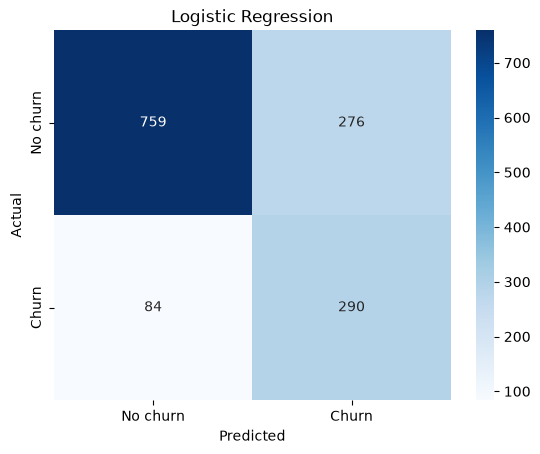

In [5]:
param_grid = {'C': [0.01, 0.1, 1, 10]}
grid_lr = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000), param_grid, scoring='f1', cv=5)
grid_lr.fit(X_train_scaled, y_train)
print(grid_lr.best_params_)
evaluate_model('Logistic Regression', grid_lr.best_estimator_, X_test_scaled, y_test)

{'C': 0.1, 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



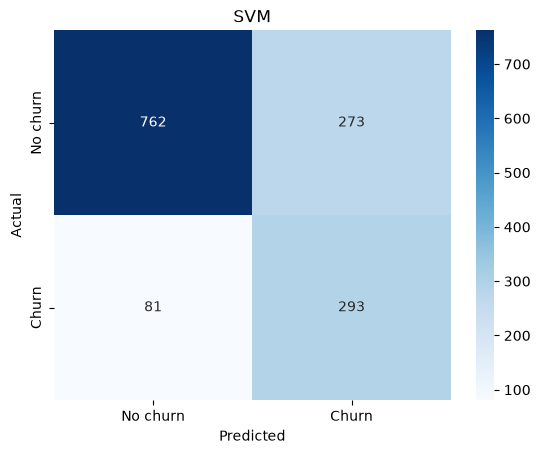

In [ ]:
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(SVC(class_weight='balanced'), param_grid, scoring='f1', cv=5)
grid_svm.fit(X_train_scaled, y_train)
print(grid_svm.best_params_)
evaluate_model('SVM', grid_svm.best_estimator_, X_test_scaled, y_test)

{'n_neighbors': 11, 'weights': 'uniform'}
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1035
           1       0.59      0.58      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



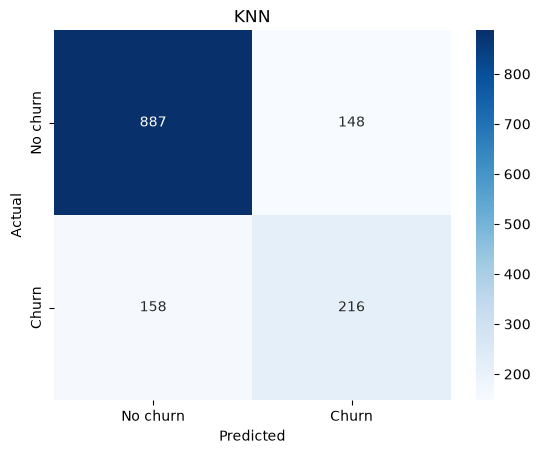

In [7]:
param_grid = {'n_neighbors': [3, 5, 7, 11, 15, 21], 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, scoring='f1', cv=5)
grid_knn.fit(X_train_scaled, y_train)
print(grid_knn.best_params_)
evaluate_model('KNN', grid_knn.best_estimator_, X_test_scaled, y_test)

{'max_depth': 10, 'min_samples_leaf': 50}
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



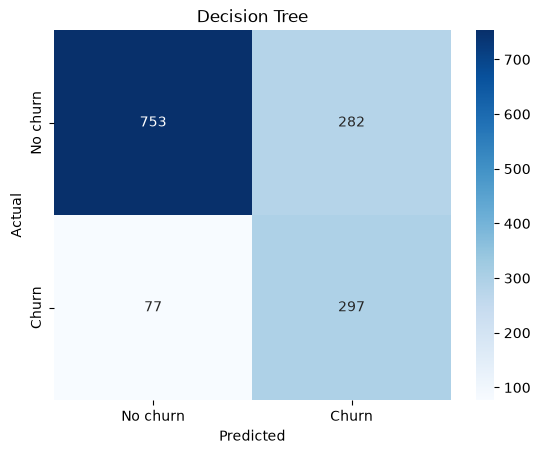

In [8]:
param_grid = {'max_depth': [3, 5, 7, 10], 'min_samples_leaf': [5, 10, 20, 50]}
grid_dt = GridSearchCV(DecisionTreeClassifier(class_weight='balanced', random_state=42), param_grid, scoring='f1', cv=5)
grid_dt.fit(X_train_scaled, y_train)
print(grid_dt.best_params_)
evaluate_model('Decision Tree', grid_dt.best_estimator_, X_test_scaled, y_test)

{'var_smoothing': 1e-09}
              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



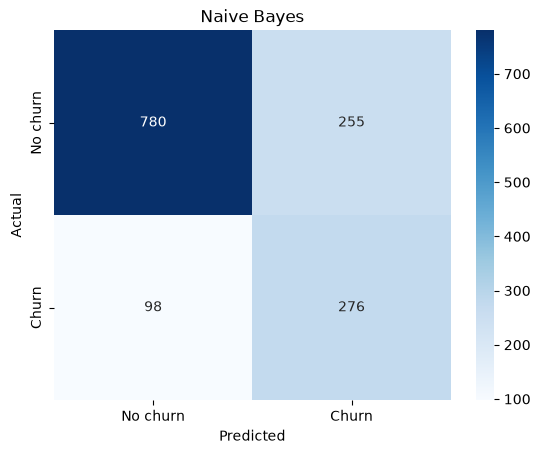

In [9]:
param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
grid_nb = GridSearchCV(GaussianNB(), param_grid, scoring='f1', cv=5)
grid_nb.fit(X_train_scaled, y_train)
print(grid_nb.best_params_)
evaluate_model('Naive Bayes', grid_nb.best_estimator_, X_test_scaled, y_test)

{'max_depth': 12, 'min_samples_leaf': 20, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.91      0.75      0.83      1035
           1       0.54      0.80      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409



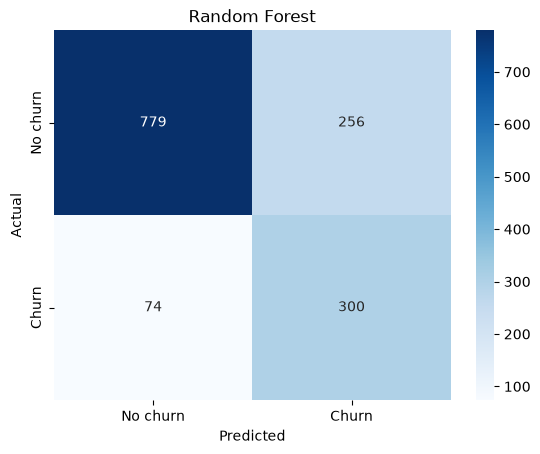

In [11]:
param_grid = {'n_estimators': [200, 400], 'max_depth': [5, 8, 12], 'min_samples_leaf': [5, 10, 20]}
grid_rf = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1), param_grid, scoring='f1', cv=5)
grid_rf.fit(X_train_scaled, y_train)
print(grid_rf.best_params_)
evaluate_model('Random Forest', grid_rf.best_estimator_, X_test_scaled, y_test)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



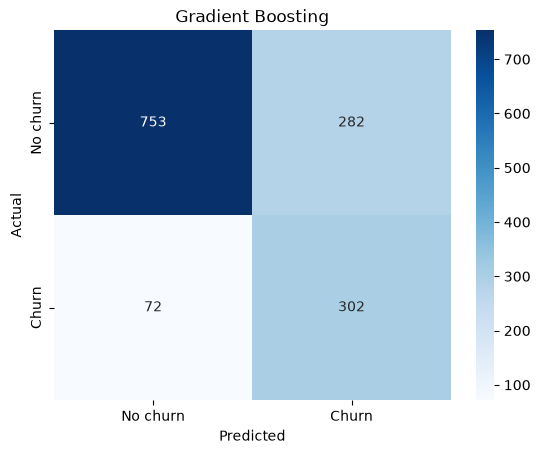

In [12]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train)

param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, scoring='f1', cv=5)
grid_gb.fit(X_train_scaled, y_train, sample_weight=sample_weights)
print(grid_gb.best_params_)
evaluate_model('Gradient Boosting', grid_gb.best_estimator_, X_test_scaled, y_test)

In [13]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.765791,0.539568,0.802139,0.645161
1,Gradient Boosting,0.748758,0.517123,0.807487,0.630480
2,SVM,0.748758,0.517668,0.783422,0.623404
3,Decision Tree,0.745209,0.512953,0.794118,0.623295
4,Logistic Regression,0.744500,0.512367,0.775401,0.617021
5,Naive Bayes,0.749468,0.519774,0.737968,0.609945
6,KNN,0.782825,0.593407,0.577540,0.585366


We recommend Random Forest. It caught about 80% of customers who actually churned while keeping false alarms lower than Gradient Boosting, giving the best F1 score (0.645). For retention, missing a churner costs more than contacting a customer who would have stayed, so we prioritised recall, then used precision to avoid wasting retention budget. KNN had the highest accuracy but missed 42% of churners, so it was rejected. Several models performed within a few points of each other, which suggests the available features limit performance more than the choice of algorithm.

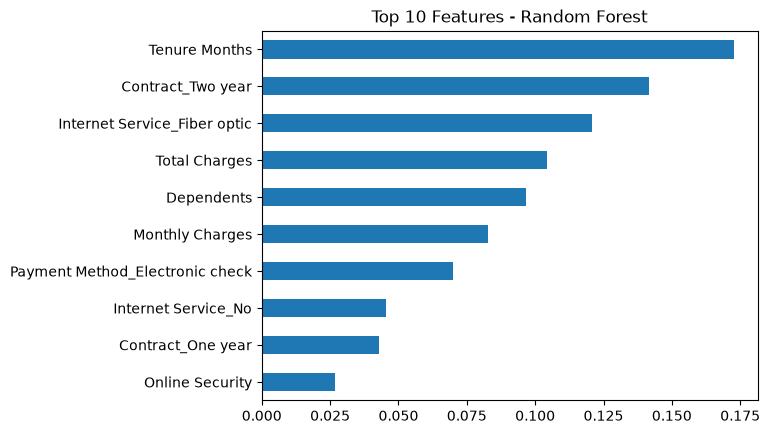

In [14]:
best_rf = grid_rf.best_estimator_

importances = pd.Series(best_rf.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Features - Random Forest')
plt.show()

In [15]:
risk = pd.DataFrame({'churn_probability': best_rf.predict_proba(X_test_scaled)[:, 1], 'actual': y_test.values})
risk.sort_values('churn_probability', ascending=False).head(10)

,churn_probability,actual
1109,0.958728,1
1221,0.956926,1
1090,0.953635,1
171,0.942270,1
1259,0.941446,1
618,0.941395,1
341,0.940731,1
1252,0.940600,1
629,0.940600,0
1289,0.937264,1
